In [ ]:
import pandas as pd
df = pd.read_csv('flight_pricing_dataset.csv')
df.head()

,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Distance_km,Travel_Class,Days_Before_Departure,Season,Weekday,Aircraft_Type,Booking_Channel,Passenger_Count,Price
0,FL133547,Indigo,Hyderabad,Ahmedabad,2025-08-02,8:10 PM,21:50,1.67,0,910.5,Economy,43,Monsoon,Saturday,Boeing 737,Mobile App,5,5181.56
1,FL133458,AirAsia India,Pune,Mumbai,2025-06-05,12:10,12:55,0h 45m,non-stop,150,Economy,45,Monsoon,Thursday,ATR 72,Website,3,2000
2,FL173851,Qatar Airways,Sydney,PNQ,2025-02-11,5:05 PM,7:53 AM,14.80,1 stop,10168.1,Economy,3,NaN,Tuesday,Boeing 777,Mobile App,3,174762.69
3,FL101953,AirAsia India,Bangalore Airport,BOM,2025-04-19,07:05,10:16 AM,3h 11m,1,868.3,Economy,33,Summer,Saturday,Airbus A320,Mobile App,1,2846.09
4,FL162887,British Airways,Sydney,Goa,2026-07-05,10:40 PM,12:36,13.93,non-stop,10478.0,Economy,6,Monsoon,Sunday,Airbus A320,Website,2,145331.64


In [ ]:
print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
df.isnull().sum()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68022 entries, 0 to 68021
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Flight_ID              68022 non-null  object
 1   Airline                64702 non-null  object
 2   Source                 64704 non-null  object
 3   Destination            64683 non-null  object
 4   Departure_Date         64714 non-null  object
 5   Departure_Time         64697 non-null  object
 6   Arrival_Time           64763 non-null  object
 7   Duration               64591 non-null  object
 8   Total_Stops            64699 non-null  object
 9   Distance_km            64715 non-null  object
 10  Travel_Class           64687 non-null  object
 11  Days_Before_Departure  64784 non-null  object
 12  Season                 64779 non-null  object
 13  Weekday                64815 non-null  object
 14  Aircraft_Type          64709 non-null  object
 15

,0
Flight_ID,0
Airline,3320
Source,3318
Destination,3339
Departure_Date,3308
Departure_Time,3325
Arrival_Time,3259
Duration,3431
Total_Stops,3323
Distance_km,3307


In [ ]:
df_cleaned = df.dropna()
print("--- Missing Values After Cleaning ---")
df_cleaned.isnull().sum()

--- Missing Values After Cleaning ---


,0
Flight_ID,0
Airline,0
Source,0
Destination,0
Departure_Date,0
Departure_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Distance_km,0


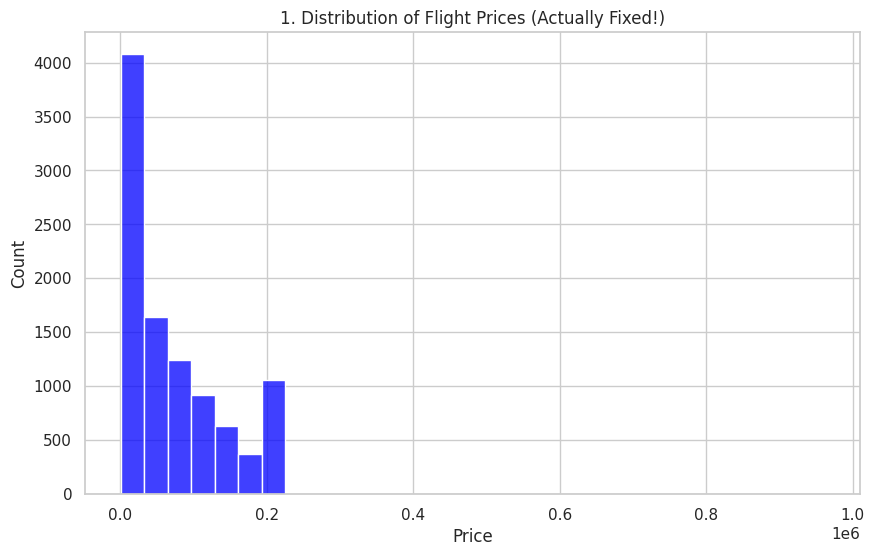

In [ ]:
df_cleaned = df.dropna().copy()
df_cleaned['Price'] = df_cleaned['Price'].astype(str).str.replace(',', '', regex=False)
df_cleaned['Price'] = df_cleaned['Price'].str.extract(r'(\d+\.?\d*)')[0]
df_cleaned['Price'] = pd.to_numeric(df_cleaned['Price'], errors='coerce')
df_cleaned = df_cleaned.dropna()
df_sample = df_cleaned.sample(n=10000, random_state=42)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(data=df_sample, x='Price', bins=30, color='blue')
plt.title("1. Distribution of Flight Prices (Actually Fixed!)")
plt.show()

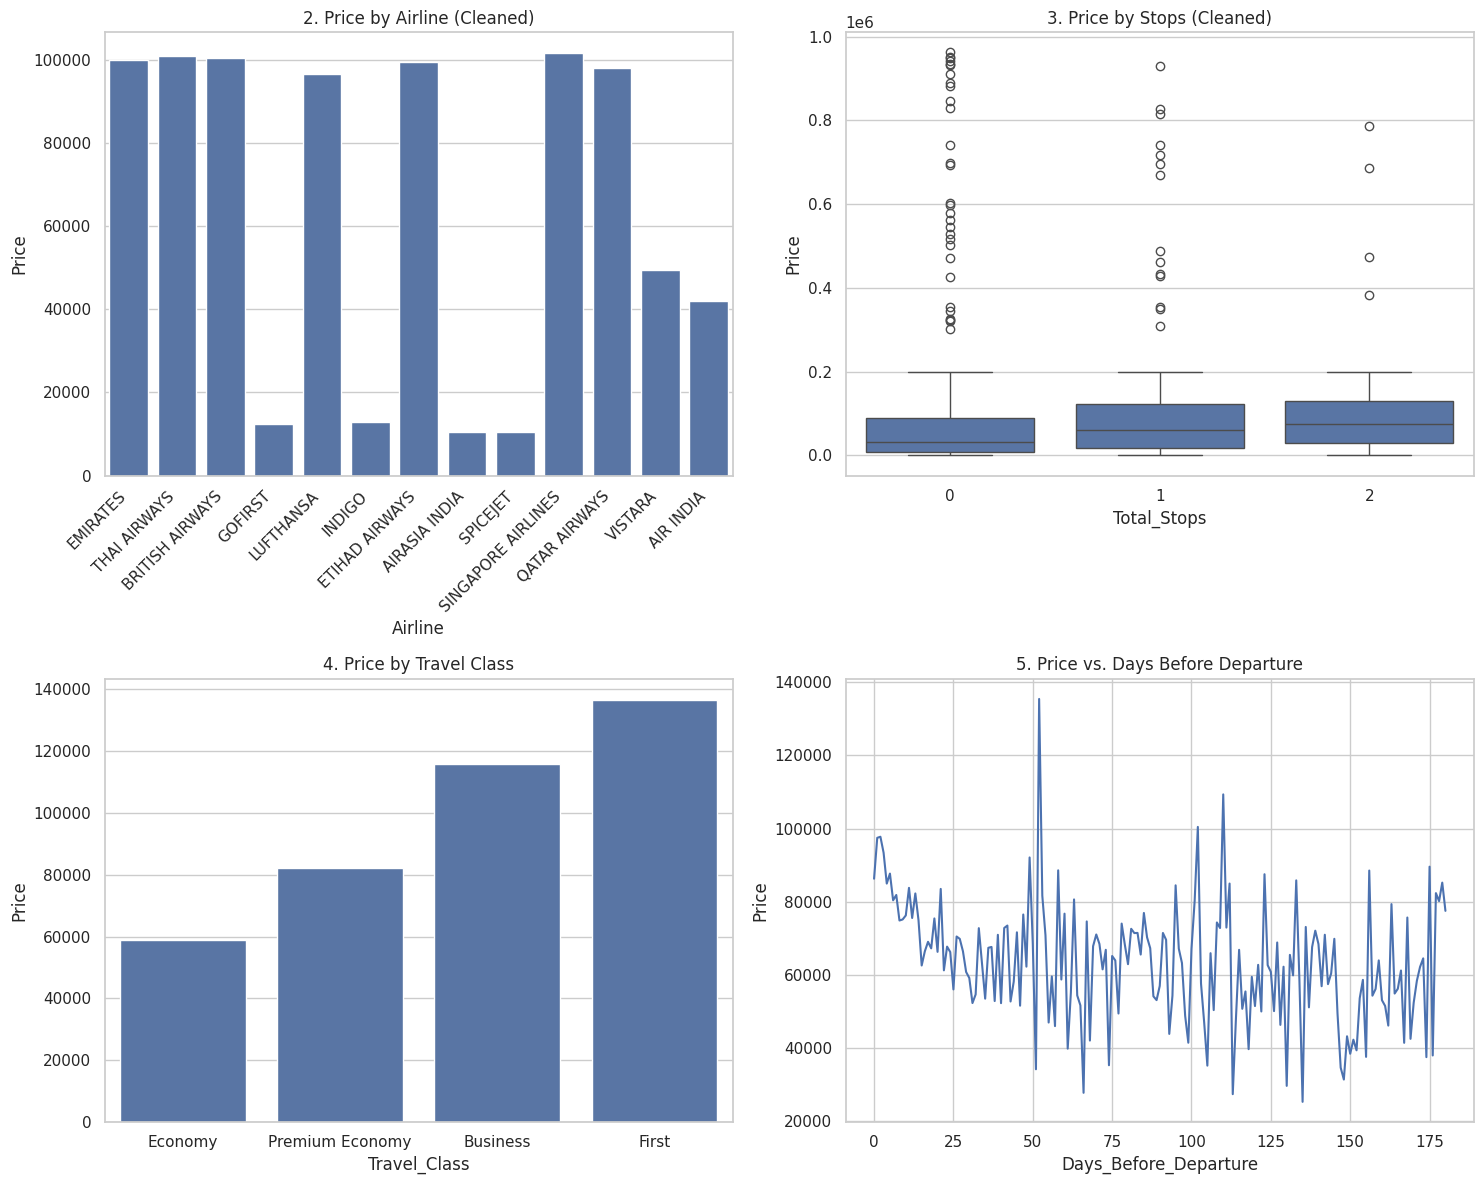

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df_cleaned['Airline'] = df_cleaned['Airline'].astype(str).str.upper()
df_cleaned['Total_Stops'] = df_cleaned['Total_Stops'].astype(str).str.lower().str.replace('non-stop', '0')
df_cleaned['Total_Stops'] = pd.to_numeric(df_cleaned['Total_Stops'].str.extract(r'(\d+)')[0])
df_cleaned['Days_Before_Departure'] = pd.to_numeric(df_cleaned['Days_Before_Departure'].astype(str).str.extract(r'(\d+)')[0])
df_sample = df_cleaned.dropna().sample(n=10000, random_state=42)
plt.figure(figsize=(15, 12))
plt.subplot(2, 2, 1)
sns.barplot(data=df_sample, x='Airline', y='Price', errorbar=None)
plt.title("2. Price by Airline (Cleaned)")
plt.xticks(rotation=45, ha='right')
plt.subplot(2, 2, 2)
sns.boxplot(data=df_sample, x='Total_Stops', y='Price')
plt.title("3. Price by Stops (Cleaned)")
plt.subplot(2, 2, 3)
sns.barplot(data=df_sample, x='Travel_Class', y='Price', errorbar=None)
plt.title("4. Price by Travel Class")
plt.subplot(2, 2, 4)
sns.lineplot(data=df_sample, x='Days_Before_Departure', y='Price', errorbar=None)
plt.title("5. Price vs. Days Before Departure")
plt.tight_layout()
plt.show()